In [1]:
!pip install pymupdf openai networkx matplotlib pyvis faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00


In [2]:
import fitz  # pymupdf
import openai
import networkx as nx
import matplotlib.pyplot as plt
import json
import re
from pathlib import Path
from google.colab import userdata

# OpenAI client
client = openai.OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

print("All imports successful")

All imports successful


In [3]:
def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    doc.close()
    return text

# Upload your PDFs to Colab first (Files panel on the left sidebar)
# Then update the filenames below to match exactly

pdf_paths = [
    "ekaa_level1.pdf",  # replace with your actual filename
    "ekaa_level2.pdf",
    "ekaa_level3.pdf",
    "ekaa_level5.pdf"
]

documents = []
for path in pdf_paths:
    text = extract_text_from_pdf(path)
    documents.append({
        "source": path,
        "text": text
    })
    print(f"{path} — {len(text)} characters extracted")

print(f"\nTotal documents loaded: {len(documents)}")

ekaa_level1.pdf — 53458 characters extracted
ekaa_level2.pdf — 120566 characters extracted
ekaa_level3.pdf — 192291 characters extracted
ekaa_level5.pdf — 98945 characters extracted

Total documents loaded: 4


In [4]:
def chunk_text(text, chunk_size=800, overlap=100):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start = end - overlap
    return chunks

all_chunks = []
for doc in documents:
    chunks = chunk_text(doc["text"])
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "source": doc["source"],
            "chunk_index": i,
            "text": chunk
        })

print(f"Total chunks created: {len(all_chunks)}")
print(f"\nSample chunk:\n{all_chunks[10]['text']}")

Total chunks created: 667

Sample chunk:
ould or should have said? 
YES 
NO 
5 
Do you tend to occasionally tune out when someone is talking to you and do 
not hear what was said because your mind drifts to something totally 
unrelated? 
YES 
NO 
6 
Do you sometimes desire to be complimented for a job well done, but feel 
embarrassed or uncomfortable when complimented? 
YES 
NO 
7 
Do you often have a fear or dread of not being able to carry on a 
conversation with someone you just met? 
YES 
NO 
8 
Do you feel self-conscious when attention is drawn to your physical body or 
appearance? 
YES 
NO 
9 
If you have a choice, would you rather avoid being around children most of 
the time? 
YES 
NO 
10 
Do you feel that you are not relaxed or loose in body movements, especially 
when faced with unfamiliar people or circumstances? 
YES 


In [5]:
def chunk_text(text, chunk_size=1000, overlap=200):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start = end - overlap
    return chunks

all_chunks = []
for doc in documents:
    chunks = chunk_text(doc["text"])
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "source": doc["source"],
            "chunk_index": i,
            "text": chunk
        })

print(f"Total chunks created: {len(all_chunks)}")
print(f"\nSample chunk:\n{all_chunks[10]['text']}")

Total chunks created: 583

Sample chunk:
o you generally feel that you see yourself less favorably than others see 
you? 
YES 
NO 
14 
Do you tend to feel awkward or self-conscious initiating touch (holding 
hands, kissing, etc.) with someone you are in a relationship with in front of 
other people? 
YES 
NO 
15 
In a new class or lecture situation do you usually feel uncomfortable asking 
questions in front of the group even though you may desire further 
explanation? 
YES 
NO 
16 
Do you feel uneasy if someone you have just met looks directly in the eyes 
when talking to you, especially if the conversation is about you? 
YES 
NO 
17 
In a group situation with people you have just met, would you feel 
uncomfortable drawing attention to yourself by initiating a conversation? 
YES 
NO 
18 
If you are in a relationship, or are very close to someone, do you find it 
difficult or embarrassing to verbalize your love for them? 
YES 
NO 
EKAA 
A Basic Course in Integrated Clinical Hypnotherap

In [6]:
# Cell 5

ENTITY_TYPES = [
    "CONCEPT",      # e.g. Trance, Consciousness, Awareness, Ego
    "TECHNIQUE",    # e.g. Pranayama, Progressive Relaxation, Visualization
    "STATE",        # e.g. Hypnotic State, Meditative State, Alpha State
    "CHAKRA",       # e.g. Root Chakra, Crown Chakra, Ajna
    "PRACTICE",     # e.g. Yoga, Hypnotherapy, Meditation
    "CONDITION",    # e.g. Anxiety, Phobia, Trauma, Stress
    "PERSON",       # e.g. Milton Erickson, Patanjali
    "BODY_PART"     # e.g. Spine, Nervous System, Diaphragm
]

RELATIONSHIP_TYPES = [
    "INDUCES",              # Pranayama INDUCES Meditative State
    "TREATS",               # Hypnotherapy TREATS Anxiety
    "PART_OF",              # Pranayama PART_OF Yoga
    "ACTIVATES",            # Breathwork ACTIVATES Root Chakra
    "REQUIRES",             # Ericksonian Hypnosis REQUIRES Rapport
    "LEADS_TO",             # Deep Relaxation LEADS_TO Trance
    "SIMILAR_TO",           # Hypnotic State SIMILAR_TO Meditative State
    "DEVELOPED_BY",         # Ericksonian Hypnosis DEVELOPED_BY Milton Erickson
    "CONTRAINDICATED_FOR"   # Deep Hypnosis CONTRAINDICATED_FOR Psychosis
]

print("Entity types defined:", len(ENTITY_TYPES))
print("Relationship types defined:", len(RELATIONSHIP_TYPES))
print("\nEntity types:", ENTITY_TYPES)
print("\nRelationship types:", RELATIONSHIP_TYPES)

Entity types defined: 8
Relationship types defined: 9

Entity types: ['CONCEPT', 'TECHNIQUE', 'STATE', 'CHAKRA', 'PRACTICE', 'CONDITION', 'PERSON', 'BODY_PART']

Relationship types: ['INDUCES', 'TREATS', 'PART_OF', 'ACTIVATES', 'REQUIRES', 'LEADS_TO', 'SIMILAR_TO', 'DEVELOPED_BY', 'CONTRAINDICATED_FOR']


In [ ]:
# Cell 6

def extract_entities_relationships(chunk_text, source):
    prompt = (
        "You are a knowledge graph extractor for a wellness and hypnotherapy domain.\n\n"
        "Extract entities, relationships, and attributes from the text below.\n\n"
        "Use ONLY these entity types:\n"
        "- CONCEPT (e.g. Trance, Consciousness, Awareness, Suggestibility, Rapport, Presupposition)\n"
        "- TECHNIQUE (e.g. Pranayama, Progressive Relaxation, Visualization, Eye Fixation)\n"
        "- STATE (e.g. Hypnotic State, Meditative State, Alpha State, Deep Relaxation)\n"
        "- CHAKRA (e.g. Root Chakra, Crown Chakra, Ajna)\n"
        "- PRACTICE (e.g. Yoga, Hypnotherapy, Meditation, NLP)\n"
        "- CONDITION (e.g. Anxiety, Phobia, Trauma, Stress, Depression)\n"
        "- EMOTION (e.g. Fear, Anger, Embarrassment, Grief, Guilt)\n"
        "- BODY_PART (e.g. Spine, Nervous System, Diaphragm, Breath)\n\n"
        "Use ONLY these relationship types:\n"
        "- INDUCES (e.g. Pranayama INDUCES Meditative State)\n"
        "- TREATS (e.g. Hypnotherapy TREATS Anxiety)\n"
        "- PART_OF (e.g. Pranayama PART_OF Yoga)\n"
        "- ACTIVATES (e.g. Breathwork ACTIVATES Root Chakra)\n"
        "- REQUIRES (e.g. Ericksonian Hypnosis REQUIRES Rapport)\n"
        "- LEADS_TO (e.g. Deep Relaxation LEADS_TO Trance)\n"
        "- SIMILAR_TO (e.g. Hypnotic State SIMILAR_TO Meditative State)\n"
        "- DEVELOPED_BY (e.g. Ericksonian Hypnosis DEVELOPED_BY Milton Erickson)\n"
        "- CONTRAINDICATED_FOR (e.g. Deep Hypnosis CONTRAINDICATED_FOR Psychosis)\n\n"
        "For ATTRIBUTES, extract the following per entity type if present in the text:\n"
        "- CHAKRA: affirmations (list), element, color, body_location, associated_qualities (list)\n"
        "- TECHNIQUE: steps (list), purpose, duration, benefits (list)\n"
        "- PRACTICE: benefits (list), contraindications (list), origin\n"
        "- CONDITION: symptoms (list), causes (list), related_emotions (list)\n"
        "- STATE: characteristics (list), how_to_achieve (list), duration\n"
        "- CONCEPT: definition, related_principles (list)\n"
        "- EMOTION: physical_sensations (list), triggers (list), related_conditions (list)\n"
        "- BODY_PART: functions (list), related_systems (list), associated_practices (list)\n\n"
        "Example output format:\n"
        "{\n"
        '  "entities": [\n'
        '    {\n'
        '      "name": "Throat Chakra",\n'
        '      "type": "CHAKRA",\n'
        '      "attributes": {\n'
        '        "affirmations": ["I speak my truth", "I express myself freely"],\n'
        '        "element": "ether",\n'
        '        "color": "blue",\n'
        '        "body_location": "throat",\n'
        '        "associated_qualities": ["communication", "self-expression"]\n'
        '      }\n'
        '    },\n'
        '    {\n'
        '      "name": "Pranayama",\n'
        '      "type": "TECHNIQUE",\n'
        '      "attributes": {\n'
        '        "steps": ["sit comfortably", "inhale deeply", "exhale slowly"],\n'
        '        "purpose": "breath control and relaxation",\n'
        '        "duration": "10-15 minutes",\n'
        '        "benefits": ["reduces stress", "improves focus"]\n'
        '      }\n'
        '    },\n'
        '    {\n'
        '      "name": "Meditative State",\n'
        '      "type": "STATE",\n'
        '      "attributes": {}\n'
        '    }\n'
        '  ],\n'
        '  "relationships": [\n'
        '    {"source": "Pranayama", "target": "Meditative State", "relation": "INDUCES"},\n'
        '    {"source": "Pranayama", "target": "Yoga", "relation": "PART_OF"}\n'
        '  ]\n'
        "}\n\n"
        "Rules:\n"
        "- Be generous in extraction. If something loosely fits an entity type, include it\n"
        "- Do not skip chunks just because the content is procedural or instructional\n"
        "- Techniques described as steps or instructions should still be extracted as TECHNIQUE\n"
        "- Concepts like suggestibility, presupposition, rapport should be extracted as CONCEPT\n"
        "- For relationships, if two entities are mentioned in the same context, infer the relationship\n"
        "- For attributes, only extract what is explicitly mentioned in the text — do not invent\n"
        "- If no attributes are found for an entity, return empty attributes: {}\n"
        "- Attributes should capture list-style content like affirmations, steps, symptoms, benefits\n"
        "- Entity names should be clean and consistent, use title case\n"
        "- Do NOT extract PERSON entities\n"
        "- If genuinely no entities exist (e.g. pure questionnaire text), return empty\n"
        "- Return ONLY valid JSON, no explanation, no extra text\n\n"
        "Text:\n"
        + chunk_text
    )

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        raw = re.sub(r"```json|```", "", raw).strip()
        result = json.loads(raw)
        return result
    except Exception as e:
        print(f"Error on chunk from {source}: {e}")
        return {"entities": [], "relationships": []}


# Full extraction on all chunks
all_extractions_v2 = []

for i, chunk in enumerate(all_chunks):
    result = extract_entities_relationships(chunk["text"], chunk["source"])
    result["source"] = chunk["source"]
    result["chunk_index"] = chunk["chunk_index"]
    all_extractions_v2.append(result)

    if i % 50 == 0:
        print(f"Processed {i}/{len(all_chunks)} chunks...")

print(f"\nExtraction complete.")
print(f"Total chunks processed: {len(all_extractions_v2)}")

total_entities = sum(len(e["entities"]) for e in all_extractions_v2)
total_relationships = sum(len(e["relationships"]) for e in all_extractions_v2)

print(f"Total entities extracted: {total_entities}")
print(f"Total relationships extracted: {total_relationships}")

# Save immediately
import json
with open("/content/all_extractions_v2.json", "w") as f:
    json.dump(all_extractions_v2, f)

print("\nSaved to all_extractions_v2.json — download this file now.")

Processed 0/583 chunks...
Processed 50/583 chunks...
Processed 100/583 chunks...
Processed 150/583 chunks...
Processed 200/583 chunks...
Processed 250/583 chunks...
Processed 300/583 chunks...
Processed 350/583 chunks...
Processed 400/583 chunks...
Processed 450/583 chunks...
Processed 500/583 chunks...
Processed 550/583 chunks...

Extraction complete.
Total chunks processed: 583
Total entities extracted: 1343
Total relationships extracted: 677

Saved to all_extractions_v2.json — download this file now.


In [7]:
# Load Cell - replaces Cell 6

import json

with open("/content/all_extractions_v2.json", "r") as f:
    all_extractions_v2 = json.load(f)

print(f"Loaded {len(all_extractions_v2)} extractions.")

Loaded 583 extractions.


In [8]:
# Cell 7 - v2

all_entities = []
all_relationships = []

for extraction in all_extractions_v2:
    all_entities.extend(extraction["entities"])
    all_relationships.extend(extraction["relationships"])

unique_entities = {}
for entity in all_entities:
    name = entity["name"].strip().title()
    entity_type = entity["type"]
    if name not in unique_entities:
        unique_entities[name] = entity_type

unique_relationships = set()
for rel in all_relationships:
    key = (rel["source"].strip().title(), rel["relation"], rel["target"].strip().title())
    unique_relationships.add(key)

print(f"Total entity mentions: {len(all_entities)}")
print(f"Unique entities: {len(unique_entities)}")
print(f"Total relationship mentions: {len(all_relationships)}")
print(f"Unique relationships: {len(unique_relationships)}")

from collections import Counter
type_counts = Counter(e["type"] for e in all_entities)
print(f"\nEntity type distribution:")
for entity_type, count in type_counts.most_common():
    print(f"  {entity_type}: {count}")

# Check attributes — how many entities have non-empty attributes
entities_with_attributes = 0
total_attribute_keys = 0
for entity in all_entities:
    attrs = entity.get("attributes", {})
    if attrs:
        entities_with_attributes += 1
        total_attribute_keys += len(attrs)

print(f"\nEntities with attributes: {entities_with_attributes}")
print(f"Total attribute fields captured: {total_attribute_keys}")

# Sample — show one entity with rich attributes
print(f"\nSample entity with attributes:")
for entity in all_entities:
    attrs = entity.get("attributes", {})
    if attrs and len(attrs) >= 2:
        print(json.dumps(entity, indent=2))
        break

Total entity mentions: 1343
Unique entities: 713
Total relationship mentions: 677
Unique relationships: 632

Entity type distribution:
  CONCEPT: 351
  CONDITION: 346
  TECHNIQUE: 192
  EMOTION: 161
  PRACTICE: 104
  STATE: 75
  BODY_PART: 70
  CHAKRA: 44

Entities with attributes: 1202
Total attribute fields captured: 3559

Sample entity with attributes:
{
  "name": "Integrated Clinical Hypnotherapy",
  "type": "PRACTICE",
  "attributes": {
    "benefits": [],
    "contraindications": [],
    "origin": "California Hypnosis Institute of India"
  }
}


In [9]:
# Quick attribute check for chakras

print("Chakra entities with attributes:\n")
for entity in all_entities:
    if entity.get("type") == "CHAKRA":
        attrs = entity.get("attributes", {})
        if attrs and any(v for v in attrs.values()):
            print(json.dumps(entity, indent=2))
            print()

Chakra entities with attributes:

{
  "name": "Crown Chakra",
  "type": "CHAKRA",
  "attributes": {
    "affirmations": [
      "I deeply and completely accept myself"
    ],
    "element": "",
    "color": "",
    "body_location": "crown",
    "associated_qualities": []
  }
}

{
  "name": "Root Chakra",
  "type": "CHAKRA",
  "attributes": {
    "affirmations": [],
    "element": "earth",
    "color": "",
    "body_location": "",
    "associated_qualities": []
  }
}

{
  "name": "Root Chakra",
  "type": "CHAKRA",
  "attributes": {
    "affirmations": [],
    "element": "earth",
    "color": "",
    "body_location": "",
    "associated_qualities": [
      "survival needs",
      "physical existence"
    ]
  }
}

{
  "name": "Root Chakra",
  "type": "CHAKRA",
  "attributes": {
    "affirmations": [
      "I am enjoying every moment of my physical existence on earth.",
      "I am open to universal guidance to shape my physical journey.",
      "I accept my contract of physical existence 

In [10]:
# Cell 7b

# Define emotions to reclassify from CONDITION to EMOTION
emotion_keywords = [
    "embarrassment", "discomfort", "fear", "anger", "sadness", "happiness",
    "joy", "guilt", "shame", "grief", "jealousy", "loneliness", "frustration",
    "resentment", "irritation", "nervousness", "worry", "disgust", "pride",
    "envy", "love", "hatred", "boredom", "confusion", "excitement", "panic"
]

# Artifacts to remove entirely
artifacts_to_remove = [
    "questionnaire no.1", "questionnaire no.2", "questionnaire no.3",
    "questionnaire", "ekaa", "client"
]

def clean_extractions(all_extractions):
    cleaned = []

    for extraction in all_extractions:
        clean_entities = []
        removed_names = set()

        for entity in extraction["entities"]:
            name = entity["name"].strip().title()
            name_lower = name.lower()
            entity_type = entity["type"]
            attributes = entity.get("attributes", {})

            # Remove artifacts
            if name_lower in artifacts_to_remove:
                removed_names.add(name)
                continue

            # Reclassify emotions from CONDITION to EMOTION
            if entity_type == "CONDITION" and any(emotion in name_lower for emotion in emotion_keywords):
                clean_entities.append({
                    "name": name,
                    "type": "EMOTION",
                    "attributes": attributes
                })
                continue

            clean_entities.append({
                "name": name,
                "type": entity_type,
                "attributes": attributes
            })

        # Clean relationships
        clean_relationships = []
        for rel in extraction["relationships"]:
            source = rel["source"].strip().title()
            target = rel["target"].strip().title()
            if source in removed_names or target in removed_names:
                continue
            clean_relationships.append(rel)

        cleaned.append({
            "entities": clean_entities,
            "relationships": clean_relationships,
            "source": extraction["source"],
            "chunk_index": extraction["chunk_index"]
        })

    return cleaned


# Run first cleaning pass
all_extractions_v2_clean = clean_extractions(all_extractions_v2)

# Second cleaning pass - specific bad entities
entities_to_remove = [
    "emotional", "physical", "chakra", "gv20", "cata", "breathing"
]

reclassify = {
    "Relaxation": "STATE",
    "Greed": "EMOTION"
}

def second_clean(all_extractions_clean):
    cleaned = []
    for extraction in all_extractions_clean:
        clean_entities = []
        removed_names = set()

        for entity in extraction["entities"]:
            name = entity["name"].strip().title()
            name_lower = name.lower()
            entity_type = entity["type"]
            attributes = entity.get("attributes", {})

            # Remove bad entities
            if name_lower in entities_to_remove:
                removed_names.add(name)
                continue

            # Reclassify
            if name in reclassify:
                clean_entities.append({
                    "name": name,
                    "type": reclassify[name],
                    "attributes": attributes
                })
                continue

            clean_entities.append({
                "name": name,
                "type": entity_type,
                "attributes": attributes
            })

        # Clean relationships
        clean_relationships = []
        for rel in extraction["relationships"]:
            source = rel["source"].strip().title()
            target = rel["target"].strip().title()
            if source in removed_names or target in removed_names:
                continue
            clean_relationships.append(rel)

        cleaned.append({
            "entities": clean_entities,
            "relationships": clean_relationships,
            "source": extraction["source"],
            "chunk_index": extraction["chunk_index"]
        })

    return cleaned


# Run second cleaning pass
all_extractions_v2_clean = second_clean(all_extractions_v2_clean)

# Recount
all_entities_clean = []
all_relationships_clean = []

for extraction in all_extractions_v2_clean:
    all_entities_clean.extend(extraction["entities"])
    all_relationships_clean.extend(extraction["relationships"])

unique_entities_clean = {}
for entity in all_entities_clean:
    name = entity["name"].strip().title()
    if name not in unique_entities_clean:
        unique_entities_clean[name] = entity["type"]

from collections import Counter
type_counts_clean = Counter(e["type"] for e in all_entities_clean)

print("Entity type distribution after cleaning:")
for entity_type, count in type_counts_clean.most_common():
    print(f"  {entity_type}: {count}")

# Sample entities per type
seen_types = {}
for name, etype in unique_entities_clean.items():
    if etype not in seen_types:
        seen_types[etype] = []
    if len(seen_types[etype]) < 5:
        seen_types[etype].append(name)

print("\nSample entities per type:")
for etype, names in seen_types.items():
    print(f"\n  {etype}: {names}")

# Verify attributes survived cleaning
entities_with_attributes = sum(
    1 for e in all_entities_clean
    if e.get("attributes") and any(v for v in e["attributes"].values())
)
print(f"\nEntities with non-empty attributes after cleaning: {entities_with_attributes}")

Entity type distribution after cleaning:
  CONCEPT: 346
  CONDITION: 311
  TECHNIQUE: 190
  EMOTION: 190
  PRACTICE: 104
  STATE: 78
  BODY_PART: 68
  CHAKRA: 42

Sample entities per type:

  CONCEPT: ['Suggestibility', 'Hypnosis', 'Depth Of Hypnosis', 'Theory Of Mind', 'Theory Of Suggestibility']

  PRACTICE: ['Integrated Clinical Hypnotherapy', 'Clinical Hypnotherapy', 'Self-Hypnosis', 'Suggestibility Questionnaire', 'Hypnotherapy']

  TECHNIQUE: ['Self Hypnosis', 'Auto Dual Induction', 'Deepening Techniques', 'Awakening Techniques', 'Eye Fascination']

  STATE: ['Hypnotic State', 'Hyper-Suggestible State', 'Hypnotic Sleep', 'Deep Sleep', 'Hypnoidal']

  EMOTION: ['Fear', 'Embarrassment', 'Defensive Emotions', 'Discomfort', 'Greed']

  BODY_PART: ['Autonomous Nervous System', 'Third Eye', 'Breath', 'Lower Extremities', 'Arms And Hands']

  CONDITION: ['Anxiety', 'Depression', 'Hyperactivity', 'Hypertension', 'Hypochondria']

  CHAKRA: ['Crown Chakra', 'Root Chakra', 'Sacral Chakra', 

In [11]:
# Cell 8

import networkx as nx

# Initialize directed graph
G = nx.DiGraph()

def merge_attributes(existing_attrs, new_attrs):
    """
    Merges new attributes into existing node attributes.
    Lists get extended, strings get filled in if empty.
    """
    for key, value in new_attrs.items():
        if key not in existing_attrs:
            existing_attrs[key] = value
        elif isinstance(value, list) and isinstance(existing_attrs[key], list):
            # Merge lists, avoid duplicates
            for item in value:
                if item and item not in existing_attrs[key]:
                    existing_attrs[key].append(item)
        elif isinstance(value, str) and value and not existing_attrs[key]:
            # Fill in empty string fields
            existing_attrs[key] = value
    return existing_attrs


# Add nodes and edges from cleaned extractions
for extraction in all_extractions_v2_clean:

    # Add entities as nodes
    for entity in extraction["entities"]:
        name = entity["name"].strip().title()
        entity_type = entity["type"]
        attributes = entity.get("attributes", {})

        if not G.has_node(name):
            # First time seeing this node — add it
            G.add_node(name, type=entity_type, attributes=attributes)
        else:
            # Node exists — merge attributes
            existing_attrs = G.nodes[name].get("attributes", {})
            merged = merge_attributes(existing_attrs, attributes)
            G.nodes[name]["attributes"] = merged

    # Add relationships as edges
    for rel in extraction["relationships"]:
        source = rel["source"].strip().title()
        target = rel["target"].strip().title()
        relation = rel["relation"]

        if G.has_node(source) and G.has_node(target):
            G.add_edge(source, target, relation=relation)


print(f"Graph built successfully.")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

# Show most connected nodes
print(f"\nTop 10 most connected entities:")
degree_sorted = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
for node, degree in degree_sorted:
    node_type = G.nodes[node].get("type", "unknown")
    print(f"  {node} ({node_type}) — {degree} connections")

# Verify attribute merging worked
print(f"\nVerifying attribute merging — Throat Chakra:")
if G.has_node("Throat Chakra"):
    attrs = G.nodes["Throat Chakra"].get("attributes", {})
    print(json.dumps(attrs, indent=2))

print(f"\nVerifying attribute merging — Root Chakra:")
if G.has_node("Root Chakra"):
    attrs = G.nodes["Root Chakra"].get("attributes", {})
    print(json.dumps(attrs, indent=2))

Graph built successfully.
Total nodes: 709
Total edges: 550

Top 10 most connected entities:
  Hypnosis (CONCEPT) — 45 connections
  Anxiety (CONDITION) — 39 connections
  Hypnotic State (STATE) — 21 connections
  Fear (EMOTION) — 20 connections
  Anger (EMOTION) — 19 connections
  Trauma (CONDITION) — 18 connections
  Mental Bank (CONCEPT) — 18 connections
  Subconscious Mind (CONCEPT) — 17 connections
  Stress (CONDITION) — 16 connections
  Suggestibility (CONCEPT) — 15 connections

Verifying attribute merging — Throat Chakra:
{
  "affirmations": [
    "I believe in myself"
  ],
  "element": "",
  "color": "",
  "body_location": "throat",
  "associated_qualities": [
    "communication",
    "self-worth",
    "self-esteem"
  ]
}

Verifying attribute merging — Root Chakra:
{
  "affirmations": [
    "I am enjoying every moment of my physical existence on earth.",
    "I am open to universal guidance to shape my physical journey.",
    "I accept my contract of physical existence on this 

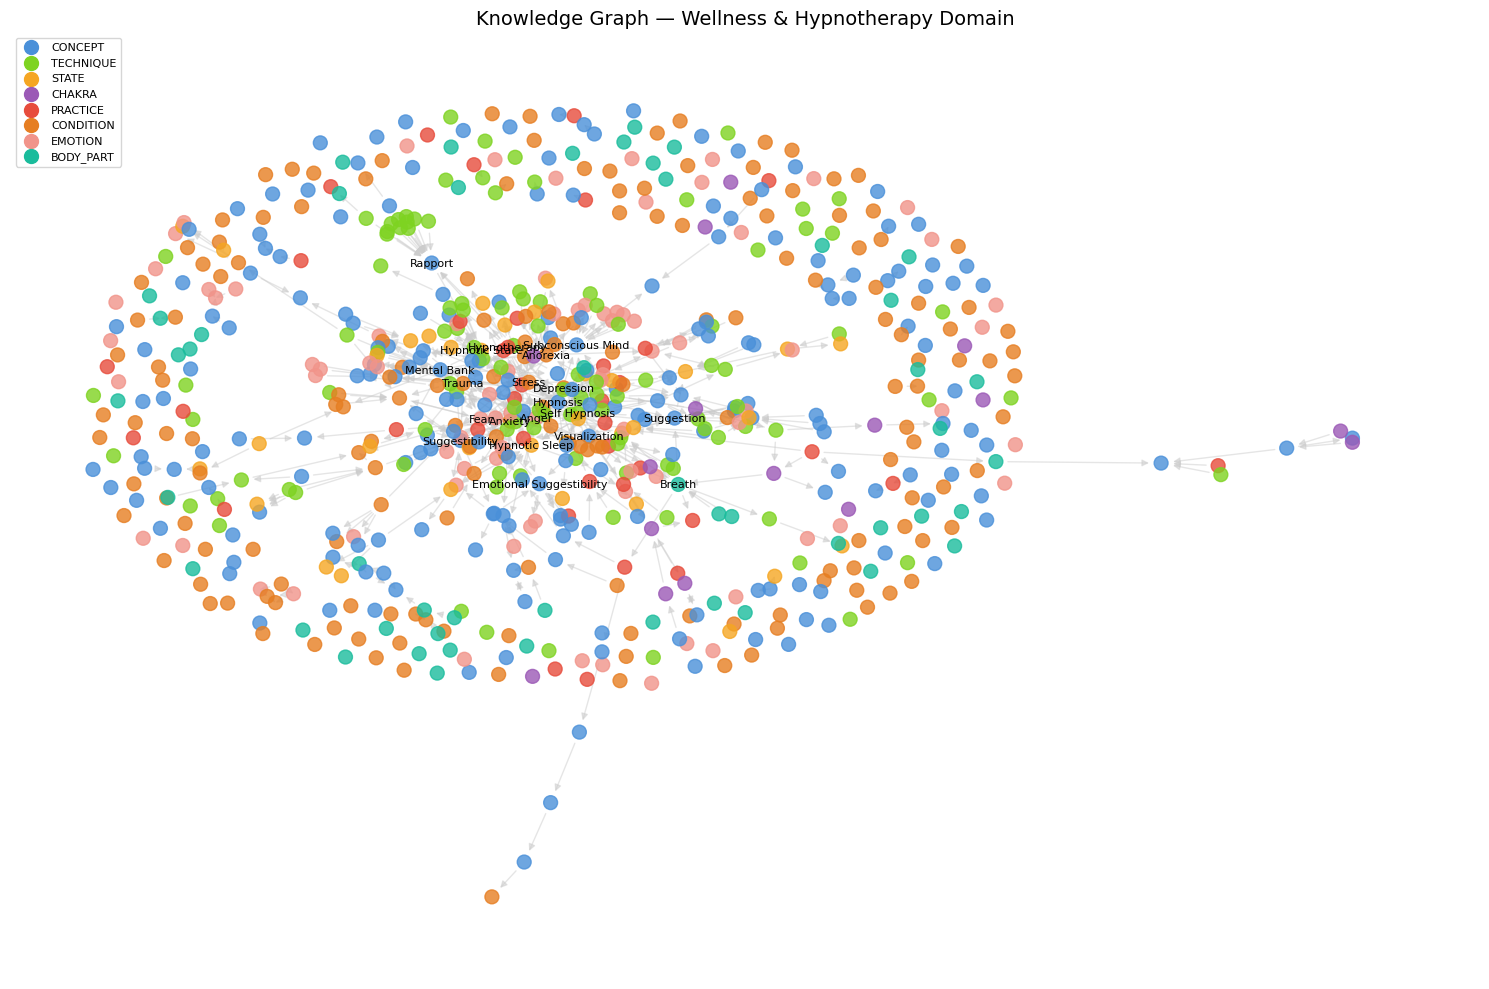

Static graph saved.
/content/knowledge_graph.html
Interactive graph saved. Download knowledge_graph.html to view in browser.


In [12]:
# Cell 9

import matplotlib.pyplot as plt
from pyvis.network import Network

# --- Part 1: Quick Matplotlib overview ---
plt.figure(figsize=(15, 10))

# Use spring layout - nodes with more connections appear more central
pos = nx.spring_layout(G, k=0.5, seed=42)

# Color nodes by entity type
color_map = {
    "CONCEPT": "#4A90D9",
    "TECHNIQUE": "#7ED321",
    "STATE": "#F5A623",
    "CHAKRA": "#9B59B6",
    "PRACTICE": "#E74C3C",
    "CONDITION": "#E67E22",
    "EMOTION": "#F1948A",
    "BODY_PART": "#1ABC9C"
}

node_colors = [color_map.get(G.nodes[node].get("type", "CONCEPT"), "#cccccc") for node in G.nodes()]

# Only label the top 20 most connected nodes to avoid clutter
top_nodes = [node for node, degree in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:20]]
labels = {node: node for node in G.nodes() if node in top_nodes}

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color="#cccccc", arrows=True, alpha=0.5)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("Knowledge Graph — Wellness & Hypnotherapy Domain", fontsize=14)
plt.axis("off")

# Add legend
legend_elements = [plt.scatter([], [], color=color, label=etype, s=100)
                   for etype, color in color_map.items()]
plt.legend(handles=legend_elements, loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("/content/knowledge_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Static graph saved.")

# --- Part 2: Interactive pyvis graph ---
net = Network(height="700px", width="100%", directed=True, notebook=True)

# Only add top 150 most connected nodes to keep it readable
top_150_nodes = [node for node, degree in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:150]]
subgraph = G.subgraph(top_150_nodes)

for node in subgraph.nodes():
    node_type = G.nodes[node].get("type", "CONCEPT")
    color = color_map.get(node_type, "#cccccc")
    net.add_node(node, label=node, color=color, title=f"{node} ({node_type})")

for source, target, data in subgraph.edges(data=True):
    relation = data.get("relation", "")
    net.add_edge(source, target, title=relation, label=relation)

net.set_options("""
{
  "physics": {
    "stabilization": true,
    "barnesHut": {
      "gravitationalConstant": -8000,
      "springLength": 150
    }
  }
}
""")

net.show("/content/knowledge_graph.html")
print("Interactive graph saved. Download knowledge_graph.html to view in browser.")

In [13]:
# Cell 10

def get_neighbors(G, entity, max_hops=1):
    """
    Get all entities directly connected to a given entity.
    max_hops=1 means immediate neighbors only.
    max_hops=2 means neighbors of neighbors too.
    """
    entity = entity.title()
    if not G.has_node(entity):
        return f"Entity '{entity}' not found in graph."

    if max_hops == 1:
        neighbors = list(G.neighbors(entity))
        incoming = list(G.predecessors(entity))

        results = []
        results.append(f"Entity: {entity} ({G.nodes[entity].get('type', 'unknown')})")
        results.append(f"\nOutgoing connections ({len(neighbors)}):")
        for n in neighbors:
            edge_data = G.get_edge_data(entity, n)
            relation = edge_data.get("relation", "RELATED_TO")
            results.append(f"  {entity} → {relation} → {n} ({G.nodes[n].get('type', 'unknown')})")

        results.append(f"\nIncoming connections ({len(incoming)}):")
        for n in incoming:
            edge_data = G.get_edge_data(n, entity)
            relation = edge_data.get("relation", "RELATED_TO")
            results.append(f"  {n} → {relation} → {entity} ({G.nodes[n].get('type', 'unknown')})")

        return "\n".join(results)

    else:
        # Multi hop - get subgraph within n hops
        nodes_in_range = nx.single_source_shortest_path_length(G, entity, cutoff=max_hops)
        subgraph_nodes = list(nodes_in_range.keys())
        results = []
        results.append(f"Entity: {entity} — {len(subgraph_nodes)} nodes within {max_hops} hops")
        for node in subgraph_nodes:
            if node != entity:
                hops = nodes_in_range[node]
                results.append(f"  {node} ({G.nodes[node].get('type', 'unknown')}) — {hops} hop(s) away")
        return "\n".join(results)


def get_shortest_path(G, source, target):
    """
    Find the shortest chain of relationships between two entities.
    This is the multi-hop reasoning capability of GraphRAG.
    """
    source = source.title()
    target = target.title()

    if not G.has_node(source):
        return f"Entity '{source}' not found in graph."
    if not G.has_node(target):
        return f"Entity '{target}' not found in graph."

    try:
        path = nx.shortest_path(G, source, target)
        results = []
        results.append(f"Shortest path from '{source}' to '{target}':")
        for i in range(len(path) - 1):
            edge_data = G.get_edge_data(path[i], path[i+1])
            relation = edge_data.get("relation", "RELATED_TO")
            results.append(f"  {path[i]} → {relation} → {path[i+1]}")
        return "\n".join(results)
    except nx.NetworkXNoPath:
        return f"No path found between '{source}' and '{target}'."


def get_subgraph_context(G, entity, max_hops=2):
    """
    Get all entities and relationships within n hops of an entity.
    This is what we pass to the LLM as context for grounded answers.
    """
    entity = entity.title()
    if not G.has_node(entity):
        return f"Entity '{entity}' not found in graph."

    # Get all nodes within max_hops
    nodes_in_range = nx.single_source_shortest_path_length(G, entity, cutoff=max_hops)
    subgraph_nodes = list(nodes_in_range.keys())
    subgraph = G.subgraph(subgraph_nodes)

    # Build context string
    results = []
    results.append(f"Knowledge graph context for: {entity}")
    results.append(f"Nodes found: {len(subgraph_nodes)}, Edges found: {subgraph.number_of_edges()}")
    results.append("\nRelationships:")

    for source, target, data in subgraph.edges(data=True):
        relation = data.get("relation", "RELATED_TO")
        source_type = G.nodes[source].get("type", "unknown")
        target_type = G.nodes[target].get("type", "unknown")
        results.append(f"  {source} ({source_type}) → {relation} → {target} ({target_type})")

    return "\n".join(results)


def find_entities_by_type(G, entity_type):
    """
    Get all entities of a specific type.
    Useful for queries like 'what techniques exist in the graph?'
    """
    entity_type = entity_type.upper()
    matches = [node for node, data in G.nodes(data=True) if data.get("type") == entity_type]
    return matches


# Test all four query functions
print("=" * 60)
print("TEST 1 - Neighbors of Hypnotherapy:")
print(get_neighbors(G, "Hypnotherapy", max_hops=1))

print("\n" + "=" * 60)
print("TEST 2 - Shortest path from Breath to Trance:")
print(get_shortest_path(G, "Breath", "Trance"))

print("\n" + "=" * 60)
print("TEST 3 - Subgraph context for Anxiety (2 hops):")
print(get_subgraph_context(G, "Anxiety", max_hops=2))

print("\n" + "=" * 60)
print("TEST 4 - All CHAKRA entities in graph:")
print(find_entities_by_type(G, "CHAKRA"))

TEST 1 - Neighbors of Hypnotherapy:
Entity: Hypnotherapy (PRACTICE)

Outgoing connections (9):
  Hypnotherapy → INDUCES → Hypnosis State (STATE)
  Hypnotherapy → REQUIRES → Rapport (CONCEPT)
  Hypnotherapy → TREATS → Anxiety (CONDITION)
  Hypnotherapy → TREATS → Anger (EMOTION)
  Hypnotherapy → REQUIRES → Cognitive Questioning (TECHNIQUE)
  Hypnotherapy → INCLUDES → Hypno-Aids (CONCEPT)
  Hypnotherapy → TREATS → Weight Control (CONDITION)
  Hypnotherapy → TREATS → Stress (CONDITION)
  Hypnotherapy → TREATS → Trauma (CONDITION)

Incoming connections (3):
  Ericksonian Hypnosis → SIMILAR_TO → Hypnotherapy (PRACTICE)
  Presupposition → PART_OF → Hypnotherapy (CONCEPT)
  Hypnodrama → PART_OF → Hypnotherapy (PRACTICE)

TEST 2 - Shortest path from Breath to Trance:
Shortest path from 'Breath' to 'Trance':
  Breath → INDUCES → Suggestion
  Suggestion → INDUCES → Trance

TEST 3 - Subgraph context for Anxiety (2 hops):
Knowledge graph context for: Anxiety
Nodes found: 47, Edges found: 86

Relat

In [14]:
# Cell 10 - Additional query functions

# Function 1 - Keyword to node matcher
def find_matching_nodes(G, keyword, top_n=3):
    """
    Maps a user query term to the closest matching nodes in the graph.
    Essential for real queries where user won't type exact node names.
    """
    keyword_lower = keyword.lower()
    matches = []

    for node in G.nodes():
        node_lower = node.lower()
        # Exact match
        if keyword_lower == node_lower:
            matches.append((node, 1.0))
        # Partial match - keyword contained in node name
        elif keyword_lower in node_lower:
            matches.append((node, 0.8))
        # Partial match - node name contained in keyword
        elif node_lower in keyword_lower:
            matches.append((node, 0.6))
        # Word level match - any word in keyword matches any word in node
        elif any(word in node_lower.split() for word in keyword_lower.split()):
            matches.append((node, 0.4))

    # Sort by match score and return top_n
    matches = sorted(matches, key=lambda x: x[1], reverse=True)[:top_n]

    if not matches:
        return f"No matching nodes found for '{keyword}'"

    print(f"Matching nodes for '{keyword}':")
    for node, score in matches:
        node_type = G.nodes[node].get("type", "unknown")
        print(f"  {node} ({node_type}) — score: {score}")

    return [node for node, score in matches]


# Function 2 - Multi entity query
def get_multi_entity_context(G, entities, max_hops=2):
    """
    Takes multiple entities and returns the union of their neighborhoods.
    Essential for questions that mention two or more concepts.
    """
    all_nodes = set()
    all_edges = []
    not_found = []

    for entity in entities:
        entity = entity.title()
        if not G.has_node(entity):
            not_found.append(entity)
            continue

        # Get nodes within max_hops for this entity
        nodes_in_range = nx.single_source_shortest_path_length(G, entity, cutoff=max_hops)
        all_nodes.update(nodes_in_range.keys())

    if not_found:
        print(f"Entities not found in graph: {not_found}")

    # Build subgraph from union of all nodes
    subgraph = G.subgraph(all_nodes)

    results = []
    results.append(f"Multi-entity context for: {', '.join(entities)}")
    results.append(f"Total nodes found: {len(all_nodes)}, Total edges: {subgraph.number_of_edges()}")
    results.append("\nRelationships:")

    for source, target, data in subgraph.edges(data=True):
        relation = data.get("relation", "RELATED_TO")
        source_type = G.nodes[source].get("type", "unknown")
        target_type = G.nodes[target].get("type", "unknown")
        results.append(f"  {source} ({source_type}) → {relation} → {target} ({target_type})")

    return "\n".join(results)


# Function 3 - Relationship filter
def get_relationships_by_type(G, relation_type, entity=None):
    """
    Get all edges of a specific relationship type across the graph.
    Optionally filter by a specific entity.
    """
    relation_type = relation_type.upper()
    results = []

    for source, target, data in G.edges(data=True):
        relation = data.get("relation", "")
        if relation == relation_type:
            if entity is None or source.title() == entity.title() or target.title() == entity.title():
                source_type = G.nodes[source].get("type", "unknown")
                target_type = G.nodes[target].get("type", "unknown")
                results.append(f"  {source} ({source_type}) → {relation} → {target} ({target_type})")

    header = f"All '{relation_type}' relationships"
    if entity:
        header += f" involving '{entity}'"
    header += f": {len(results)} found"

    return header + "\n" + "\n".join(results)


# Test all three new functions

print("=" * 60)
print("TEST 5 - Keyword matcher for 'throat chakra':")
find_matching_nodes(G, "throat chakra")

print("\n" + "=" * 60)
print("TEST 6 - Multi entity query for Breath + Chakra:")
print(get_multi_entity_context(G, ["Breath", "Chakra"], max_hops=2))

print("\n" + "=" * 60)
print("TEST 7 - All TREATS relationships involving Anxiety:")
print(get_relationships_by_type(G, "TREATS", entity="Anxiety"))

TEST 5 - Keyword matcher for 'throat chakra':
Matching nodes for 'throat chakra':
  Throat Chakra (CHAKRA) — score: 1.0
  Basic Chakra Diagnosis (TECHNIQUE) — score: 0.4
  Crown Chakra (CHAKRA) — score: 0.4

TEST 6 - Multi entity query for Breath + Chakra:
Entities not found in graph: ['Chakra']
Multi-entity context for: Breath, Chakra
Total nodes found: 15, Total edges: 18

Relationships:
  Deep Sleep (STATE) → INDUCES → Suggestion (CONCEPT)
  Relaxation (STATE) → INDUCES → Hypnotic Sleep (STATE)
  Relaxation (STATE) → LEADS_TO → Stress (CONDITION)
  Relaxation (STATE) → LEADS_TO → Trauma (CONDITION)
  Breathing For Relaxation (PRACTICE) → INDUCES → Conscious Mind (CONCEPT)
  Breathing For Relaxation (PRACTICE) → INDUCES → Sub-Conscious Mind (CONCEPT)
  Deep Breathing (TECHNIQUE) → INDUCES → Comfortable Position (STATE)
  Suggestion (CONCEPT) → INDUCES → Deep Sleep (STATE)
  Suggestion (CONCEPT) → INDUCES → Trance (STATE)
  Suggestion (CONCEPT) → LEADS_TO → Emotional Feelings (EMOTION

In [15]:
# Cell 10b - Remove bad edges from graph

# Define bad edges to remove - (source, target)
bad_edges = [
    ("Anxiety", "Emotional Stability"),
    ("Anxiety", "Impotence"),
    ("Fear Of Failure", "Anxiety"),
    ("Fear Of Success", "Anxiety"),
    ("Tardiness", "Anxiety"),
    ("Defense Mechanism", "Anxiety"),
    ("Nail Biting", "Anxiety"),
    ("Premature Ejaculation", "Anxiety"),
    ("Anorexic State", "Anxiety"),
    ("Anxiety", "Sexual Response"),
]

removed = 0
for source, target in bad_edges:
    if G.has_edge(source, target):
        G.remove_edge(source, target)
        print(f"Removed: {source} → {target}")
        removed += 1
    else:
        print(f"Edge not found: {source} → {target}")

print(f"\nTotal edges removed: {removed}")
print(f"Graph now has {G.number_of_edges()} edges")

# Verify by rechecking TREATS relationships for Anxiety
print("\nUpdated TREATS relationships involving Anxiety:")
print(get_relationships_by_type(G, "TREATS", entity="Anxiety"))

Edge not found: Anxiety → Emotional Stability
Removed: Anxiety → Impotence
Removed: Fear Of Failure → Anxiety
Removed: Fear Of Success → Anxiety
Removed: Tardiness → Anxiety
Edge not found: Defense Mechanism → Anxiety
Removed: Nail Biting → Anxiety
Removed: Premature Ejaculation → Anxiety
Removed: Anorexic State → Anxiety
Removed: Anxiety → Sexual Response

Total edges removed: 8
Graph now has 542 edges

Updated TREATS relationships involving Anxiety:
All 'TREATS' relationships involving 'Anxiety': 11 found
  Hypnosis (CONCEPT) → TREATS → Anxiety (CONDITION)
  Visualization (CONCEPT) → TREATS → Anxiety (CONDITION)
  Hypnotherapy (PRACTICE) → TREATS → Anxiety (CONDITION)
  Emotional Freedom Techniques (TECHNIQUE) → TREATS → Anxiety (CONDITION)
  Hypno-Drama (TECHNIQUE) → TREATS → Anxiety (CONDITION)
  Emotion Management Technique (TECHNIQUE) → TREATS → Anxiety (CONDITION)
  Nlp (PRACTICE) → TREATS → Anxiety (CONDITION)
  Hypnodrama (PRACTICE) → TREATS → Anxiety (CONDITION)
  Hidden Obse

In [20]:
# Cell 11

from sentence_transformers import SentenceTransformer, util
import numpy as np
import faiss

# Load sentence transformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Pre-embed all node names for semantic matching
node_names = list(G.nodes())
print("Embedding node names for semantic matching...")
node_embeddings = embedder.encode(node_names, convert_to_tensor=True)
print(f"Embedded {len(node_names)} nodes.")

# Note: FAISS index no longer used for fallback
# Keeping it for potential future use
print("Building FAISS index for node matching...")
chunk_texts = [chunk["text"] for chunk in all_chunks]
chunk_embeddings_np = embedder.encode(chunk_texts, convert_to_numpy=True, show_progress_bar=False)
dimension = chunk_embeddings_np.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(chunk_embeddings_np)
print(f"FAISS index built with {faiss_index.ntotal} chunks.")

# Conversation memory
conversation_history = []


# ─────────────────────────────────────────────
# Step 1 — Query Classifier
# ─────────────────────────────────────────────
def classify_query(query, conversation_history):
    history_text = ""
    if conversation_history:
        recent = conversation_history[-4:]
        history_text = "\n".join([f"{m['role']}: {m['content']}" for m in recent])

    prompt = (
        "You are a query classifier for a wellness and hypnotherapy knowledge system.\n\n"
        "Given the conversation history and current query, answer two questions:\n"
        "1. Is the query CLEAR or VAGUE?\n"
        "   - VAGUE if it contains pronouns like 'its', 'it', 'they', 'their', 'this', 'that', 'these'\n"
        "   - VAGUE if it is a follow-up question without explicit entity names\n"
        "   - VAGUE if it cannot be understood without reading previous messages\n"
        "   - CLEAR only if it contains explicit entity names and can be understood standalone\n"
        "2. Is the query SIMPLE or COMPLEX?\n"
        "   - COMPLEX if it asks for types, categories, lists, comparisons, or how things relate\n"
        "   - COMPLEX if it involves multiple concepts\n"
        "   - SIMPLE only if it asks about a single specific concept\n\n"
        "Return ONLY valid JSON:\n"
        '{"clarity": "clear" or "vague", "complexity": "simple" or "complex"}\n\n'
        f"Conversation history:\n{history_text}\n\n"
        f"Current query: {query}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()
    return json.loads(raw)


# ─────────────────────────────────────────────
# Step 2 — Query Rewriter
# ─────────────────────────────────────────────
def rewrite_query(query, conversation_history):
    recent = conversation_history[-4:]
    history_text = "\n".join([f"{m['role']}: {m['content']}" for m in recent])

    prompt = (
        "You are a query rewriter for a wellness and hypnotherapy knowledge system.\n\n"
        "Using the conversation history, rewrite the vague query into a clear, specific query "
        "that mentions explicit entity names from the domain.\n"
        "Return ONLY the rewritten query as plain text, nothing else.\n\n"
        f"Conversation history:\n{history_text}\n\n"
        f"Vague query: {query}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content.strip()


# ─────────────────────────────────────────────
# Step 3 — Keyword Extractor
# ─────────────────────────────────────────────
def extract_keywords(query):
    prompt = (
        "Extract entity names from the query that could exist in a knowledge graph "
        "covering wellness, hypnotherapy, psychology, family systems, and human behavior.\n\n"
        "Rules:\n"
        "- Extract compound phrases as single entities where possible\n"
        "  e.g. 'types of breathing for relaxation' → 'Breathing For Relaxation', 'Breathing Techniques'\n"
        "  e.g. 'throat chakra affirmations' → 'Throat Chakra', 'Affirmation'\n"
        "  e.g. 'hypnotherapy for anxiety' → 'Hypnotherapy', 'Anxiety'\n"
        "  e.g. 'traits of dysfunctional family' → 'Dysfunctional Family'\n"
        "  e.g. 'roles of children in dysfunctional families' → 'Dysfunctional Family', 'Children Roles'\n"
        "  e.g. 'corrective therapy' → 'Corrective Therapy'\n"
        "  e.g. 'law of repetition' → 'Law Of Repetition'\n"
        "  e.g. 'healthy family' → 'Healthy Family'\n"
        "- Do NOT extract generic standalone words like 'types', 'different', 'traits', 'roles'\n"
        "  unless they are clearly standalone entities on their own\n"
        "- Prefer specific compound phrases over generic single words\n"
        "- Entity types to look for: concepts, techniques, states, chakras, practices, "
        "conditions, emotions, body parts, family systems, psychological concepts, therapy types\n\n"
        "Return ONLY a JSON array of strings, nothing else.\n"
        'Example: ["Dysfunctional Family", "Corrective Therapy", "Law Of Repetition"]\n\n'
        f"Query: {query}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()
    return json.loads(raw)


# ─────────────────────────────────────────────
# Step 4 — Hybrid Keyword Matcher
# ─────────────────────────────────────────────
def match_keywords_to_nodes(keywords, query=None, top_n=2):
    matched_nodes = []

    # Pass 0 - compound phrase match using full query
    if query:
        query_lower = query.lower()
        for node in G.nodes():
            node_lower = node.lower()
            if node_lower in query_lower and len(node_lower) > 5:
                matched_nodes.append(node)

    # Pass 0b - type-aware search
    type_indicators = ["types of", "different types", "kinds of", "forms of"]
    query_lower = query.lower() if query else ""

    if any(indicator in query_lower for indicator in type_indicators):
        for keyword in keywords:
            keyword_lower = keyword.lower()
            core_words = [w for w in keyword_lower.split()
                         if w not in ["for", "of", "the", "a", "an", "types",
                                      "techniques", "different", "kinds", "forms"]]
            for core_word in core_words:
                if len(core_word) > 4:
                    for node in G.nodes():
                        if core_word in node.lower() and node not in matched_nodes:
                            matched_nodes.append(node)

    # Pass 1 - per keyword string matching
    for keyword in keywords:
        keyword_lower = keyword.lower()
        string_matches = []

        for node in G.nodes():
            node_lower = node.lower()
            if keyword_lower == node_lower:
                string_matches.append((node, 1.0))
            elif keyword_lower in node_lower:
                string_matches.append((node, 0.8))
            elif node_lower in keyword_lower:
                string_matches.append((node, 0.6))
            elif any(word in node_lower.split()
                    for word in keyword_lower.split()
                    if len(word) > 4):
                string_matches.append((node, 0.4))

        if string_matches:
            best = sorted(string_matches, key=lambda x: x[1], reverse=True)[:top_n]
            matched_nodes.extend([node for node, score in best])
        else:
            # Pass 2 - semantic fallback
            keyword_embedding = embedder.encode(keyword, convert_to_tensor=True)
            scores = util.cos_sim(keyword_embedding, node_embeddings)[0]
            top_indices = scores.argsort(descending=True)[:top_n]
            for idx in top_indices:
                matched_nodes.append(node_names[idx])

    return list(set(matched_nodes))


# ─────────────────────────────────────────────
# Step 5 — Graph Context Retriever with Per-Node Budget
# ─────────────────────────────────────────────
def retrieve_graph_context(matched_nodes, complexity):
    max_hops = 1 if complexity == "simple" else 2
    max_nodes = 20 if complexity == "simple" else 40

    priority_nodes = []
    for entity in matched_nodes:
        entity = entity.title()
        if G.has_node(entity):
            priority_nodes.append(entity)

    if not priority_nodes:
        return "No matching entities found in graph."

    remaining_slots = max_nodes - len(priority_nodes)
    budget_per_node = max(1, remaining_slots // len(priority_nodes))

    all_nodes = list(priority_nodes)
    seen = set(priority_nodes)

    for entity in priority_nodes:
        nodes_in_range = nx.single_source_shortest_path_length(
            G, entity, cutoff=max_hops
        )
        sorted_neighbors = sorted(
            nodes_in_range.items(), key=lambda x: x[1]
        )
        count = 0
        for node, hops in sorted_neighbors:
            if node not in seen and count < budget_per_node:
                all_nodes.append(node)
                seen.add(node)
                count += 1

    subgraph = G.subgraph(all_nodes)

    context_lines = []
    context_lines.append(
        f"Graph context — {len(all_nodes)} nodes, {subgraph.number_of_edges()} edges:"
    )

    context_lines.append("\nEntity attributes:")
    for node in all_nodes:
        if not G.has_node(node):
            continue
        attrs = G.nodes[node].get("attributes", {})
        if attrs and any(v for v in attrs.values()):
            node_type = G.nodes[node].get("type", "unknown")
            context_lines.append(f"\n  {node} ({node_type}):")
            for key, value in attrs.items():
                if value:
                    context_lines.append(f"    {key}: {value}")

    context_lines.append("\nRelationships:")
    for source, target, data in subgraph.edges(data=True):
        relation = data.get("relation", "RELATED_TO")
        source_type = G.nodes[source].get("type", "unknown")
        target_type = G.nodes[target].get("type", "unknown")
        context_lines.append(
            f"  {source} ({source_type}) → {relation} → {target} ({target_type})"
        )

    return "\n".join(context_lines)


# ─────────────────────────────────────────────
# Step 6 — Context Quality Check
# ─────────────────────────────────────────────
def is_context_sufficient(graph_context, complexity="simple"):
    first_line = graph_context.split("\n")[0]
    try:
        nodes_count = int(first_line.split("nodes")[0].split("—")[1].strip())
        edges_count = int(first_line.split("edges")[0].split(",")[1].strip())
    except:
        return False

    min_nodes = 1 if complexity == "simple" else 2
    min_edges = 1 if complexity == "simple" else 2
    min_chars = 200 if complexity == "simple" else 500

    if nodes_count < min_nodes:
        return False
    if edges_count < min_edges:
        return False
    if len(graph_context) < min_chars:
        return False

    return True


# ─────────────────────────────────────────────
# Step 7 — Chunk Fallback using RAG hybrid search
# ─────────────────────────────────────────────
def retrieve_chunks_fallback(query, top_k=5):
    """
    Uses RAG system's hybrid search for fallback retrieval.
    More accurate than sentence-transformer FAISS.
    Uses OpenAI embeddings + BM25 — same as original RAG project.
    """
    results = rag_hybrid_search(query, k=top_k)
    retrieved = [r["doc"].page_content for r in results]
    return "\n\n---\n\n".join(retrieved)


# ─────────────────────────────────────────────
# Step 8 — Conversation Summarizer
# ─────────────────────────────────────────────
def summarize_history(conversation_history):
    if len(conversation_history) <= 6:
        return conversation_history

    history_text = "\n".join([f"{m['role']}: {m['content']}"
                               for m in conversation_history[:-4]])

    prompt = (
        "Summarize the following conversation in 3-4 sentences, "
        "preserving key topics and entities discussed.\n\n"
        f"Conversation:\n{history_text}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    summary = response.choices[0].message.content.strip()

    return (
        [{"role": "system", "content": f"Earlier conversation summary: {summary}"}]
        + conversation_history[-4:]
    )


# ─────────────────────────────────────────────
# Step 9 — LLM Self Assessment
# ─────────────────────────────────────────────
def assess_answer_quality(query, answer):
    prompt = (
        "You are evaluating whether an answer sufficiently addresses a question.\n"
        "Answer with ONLY 'yes' or 'no'.\n\n"
        "Mark as 'yes' if the answer:\n"
        "- Provides at least some relevant specific information\n"
        "- Does not say it has no information at all\n"
        "- Makes a genuine attempt to address the question\n\n"
        "Mark as 'no' ONLY if the answer:\n"
        "- Explicitly says it has no information\n"
        "- Is completely off-topic\n"
        "- Is a single sentence with no substance\n\n"
        f"Question: {query}\n"
        f"Answer: {answer}\n\n"
        "Is this answer sufficient? (yes/no)"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    result = response.choices[0].message.content.strip().lower()
    return "yes" in result


# ─────────────────────────────────────────────
# Step 10 — GraphRAG Answer Generator
# ─────────────────────────────────────────────
def graphrag_answer(query):
    global conversation_history

    print(f"\nQuery: {query}")
    print("-" * 50)

    # Step 1 - Classify
    classification = classify_query(query, conversation_history)
    clarity = classification.get("clarity", "clear")
    complexity = classification.get("complexity", "simple")
    print(f"Classified as: {clarity} | {complexity}")

    # Step 2 - Rewrite if vague
    final_query = query
    if clarity == "vague" and conversation_history:
        final_query = rewrite_query(query, conversation_history)
        print(f"Rewritten query: {final_query}")

    # Step 3 - Extract keywords
    keywords = extract_keywords(final_query)
    print(f"Extracted keywords: {keywords}")

    # Step 4 - Match to graph nodes
    matched_nodes = match_keywords_to_nodes(keywords, query=final_query)
    print(f"Matched nodes: {matched_nodes}")

    # Step 5 - Retrieve graph context
    graph_context = retrieve_graph_context(matched_nodes, complexity)
    print(f"Context retrieved: {len(graph_context)} characters")

    # Step 6 - Pre-generation context quality check
    # Always use original query for fallback — more precise than rewritten query
    if not is_context_sufficient(graph_context, complexity):
        print("Graph context insufficient — going directly to fallback")
        chunk_context = retrieve_chunks_fallback(query, top_k=5)

        fallback_prompt = (
            "You are a knowledgeable wellness and hypnotherapy assistant.\n"
            "Use the document context below to answer the question.\n"
            "Only use information explicitly present in the context.\n"
            "Do not invent or infer information not present in the context.\n\n"
            f"Document context:\n{chunk_context}\n\n"
            f"User question: {query}"
        )

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": fallback_prompt}],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()
        conversation_history.append({"role": "user", "content": query})
        conversation_history.append({"role": "assistant", "content": answer})
        print(f"\nFinal Answer (fallback):\n{answer}")
        return answer

    # Step 7 - Summarize history if long
    conversation_history = summarize_history(conversation_history)

    # Step 8 - Build history text
    history_text = "\n".join([f"{m['role']}: {m['content']}"
                               for m in conversation_history[-4:]])

    # Step 9 - Generate initial answer from graph context
    prompt = (
        "You are a knowledgeable wellness and hypnotherapy assistant.\n"
        "Answer the user's question using the graph context provided below.\n"
        "The context includes entity attributes (like affirmations, steps, benefits) "
        "and relationships between entities.\n"
        "Use attributes first when answering — they contain specific details.\n"
        "If the graph context does not contain enough information, say so honestly.\n"
        "Keep answers clear and structured.\n\n"
        f"Conversation history:\n{history_text}\n\n"
        f"Graph context:\n{graph_context}\n\n"
        f"User question: {final_query}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    answer = response.choices[0].message.content.strip()

    print(f"\nInitial graph answer:\n{answer}")
    print("-" * 50)

    # Step 10 - LLM self assessment
    is_sufficient = assess_answer_quality(final_query, answer)
    print(f"Answer self-assessment: {'sufficient' if is_sufficient else 'insufficient — triggering fallback'}")

    if not is_sufficient:
        print("Falling back to chunk retrieval...")
        chunk_context = retrieve_chunks_fallback(query, top_k=5)

        fallback_prompt = (
            "You are a knowledgeable wellness and hypnotherapy assistant.\n"
            "The initial graph-based answer was insufficient. "
            "Use the additional document context below to provide a complete answer.\n"
            "Only use information that is explicitly present in the document context.\n"
            "Do not invent or infer information not present in the context.\n\n"
            f"Initial answer: {answer}\n\n"
            f"Additional document context:\n{chunk_context}\n\n"
            f"User question: {query}"
        )

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": fallback_prompt}],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()
        print("Fallback answer generated.")

    # Update memory
    conversation_history.append({"role": "user", "content": query})
    conversation_history.append({"role": "assistant", "content": answer})

    print(f"\nFinal Answer:\n{answer}")
    return answer


# ─────────────────────────────────────────────
# Test the full pipeline
# ─────────────────────────────────────────────

conversation_history = []

graphrag_answer("tell me about throat chakra")
graphrag_answer("what are its affirmations?")
graphrag_answer("what are the different types of breathing for relaxation?")
graphrag_answer("Tell me about corrective therapy")
graphrag_answer("Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding node names for semantic matching...
Embedded 709 nodes.
Building FAISS index for node matching...
FAISS index built with 583 chunks.

Query: tell me about throat chakra
--------------------------------------------------
Classified as: clear | simple
Extracted keywords: ['Throat Chakra']
Matched nodes: ['Basic Chakra Diagnosis', 'Throat Chakra']
Context retrieved: 361 characters

Initial graph answer:
The Throat Chakra, also known as Vishuddha, is located in the throat area and is associated with several key attributes:

- **Affirmations**: A powerful affirmation for the Throat Chakra is "I believe in myself." This affirmation can help enhance self-expression and confidence.
- **Body Location**: As mentioned, it is situated in the throat.
- **Associated Qualities**: The Throat Chakra is linked to important qualities such as communication, self-worth, and self-esteem.

Additionally, the Throat Chakra is interconnected with the concept of Clairaudience, meaning that it both requ

"In the context of family dynamics and emotional well-being, a dysfunctional family is characterized by several specific traits:\n\n1. **Symptoms**:\n   - **Emotional Abuse**: Patterns of behavior that harm a family member's emotional well-being.\n   - **Physical Abuse**: Any form of physical harm inflicted on family members.\n   - **Sexual Abuse**: Inappropriate sexual behavior or exploitation within the family.\n   - **Shame**: A pervasive feeling of shame among family members.\n   - **Enmeshed Relationships**: Lack of personal boundaries, where family members are overly involved in each other's lives.\n   - **Lack of Personal Boundaries**: Difficulty in establishing and respecting individual limits.\n   - **Discouraged Expression of Feelings**: Family members are not encouraged to share their emotions openly.\n   - **Manipulation**: Use of deceit or coercion to control family members.\n   - **Grim Atmosphere**: A generally negative or oppressive environment within the family.\n\n2. 

In [17]:
# Move files into faiss_index folder

import os
os.makedirs("/content/faiss_index", exist_ok=True)
os.rename("/content/index.faiss", "/content/faiss_index/index.faiss")
os.rename("/content/index.pkl", "/content/faiss_index/index.pkl")

print("Files moved successfully.")
print(os.listdir("/content/faiss_index"))

Files moved successfully.
['index.pkl', 'index.faiss']


In [18]:
# Cell 12 installs

!pip install langchain-openai langchain-community rank_bm25 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [19]:
# Cell 12

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from rank_bm25 import BM25Okapi
from google.colab import userdata
import numpy as np

# Load FAISS index and build BM25
print("Loading RAG resources...")

rag_embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=userdata.get('OPENAI_API_KEY')
)

rag_vector_store = FAISS.load_local(
    "/content/faiss_index",
    rag_embeddings,
    allow_dangerous_deserialization=True
)

rag_docs = list(rag_vector_store.docstore._dict.values())
tokenized = [doc.page_content.lower().split() for doc in rag_docs]
bm25 = BM25Okapi(tokenized)

rag_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=userdata.get('OPENAI_API_KEY')
)

print(f"RAG index loaded. Total docs: {len(rag_docs)}")

# Conversation history for RAG
rag_conversation_history = []


def rag_rewrite_query(query, history_text):
    if not history_text:
        return query
    recent_history = "\n".join(history_text.split("\n")[-4:])
    rewrite_prompt = (
        f"Given this recent conversation:\n{recent_history}\n\n"
        "Rewrite this question as a complete standalone question.\n"
        "If it already makes complete sense on its own, return it unchanged.\n\n"
        f'Question: "{query}"\n\n'
        "Return only the rewritten question, nothing else."
    )
    return rag_llm.invoke(rewrite_prompt).content.strip()


def rag_hybrid_search(query, k=3, semantic_weight=0.7):
    semantic_results = rag_vector_store.similarity_search_with_score(query, k=k)
    tokenized_query = query.lower().split()
    bm25_scores = bm25.get_scores(tokenized_query)
    top_bm25_indices = np.argsort(bm25_scores)[::-1][:k]

    combined = {}
    for doc, score in semantic_results:
        key = doc.page_content[:50]
        combined[key] = {
            "doc": doc,
            "score": semantic_weight * (1 / (1 + score))
        }
    for idx in top_bm25_indices:
        doc = rag_docs[idx]
        key = doc.page_content[:50]
        bm25_score = (1 - semantic_weight) * (bm25_scores[idx] / (bm25_scores.max() + 1e-9))
        if key in combined:
            combined[key]["score"] += bm25_score
        else:
            combined[key] = {"doc": doc, "score": bm25_score}

    results = sorted(combined.values(), key=lambda x: x["score"], reverse=True)
    return results[:k]


def rag_answer(query):
    global rag_conversation_history

    print(f"\nRAG Query: {query}")
    print("-" * 50)

    # Build history text
    history_text = ""
    for m in rag_conversation_history:
        role = "User" if m["role"] == "user" else "Assistant"
        history_text += f"{role}: {m['content']}\n"

    # Rewrite query if needed
    search_query = rag_rewrite_query(query, history_text)
    if search_query != query:
        print(f"Rewritten query: {search_query}")

    # Hybrid search
    results = rag_hybrid_search(search_query, k=3)
    filtered = [r for r in results if r["score"] > 0.3]
    if not filtered:
        filtered = results[:2]

    context = "\n\n".join([r["doc"].page_content for r in filtered])
    top_score = filtered[0]["score"] if filtered else 0
    print(f"Top retrieval score: {top_score:.3f}")

    # Generate answer
    final_prompt = (
        "You are a helpful assistant. Use the context below to answer the question.\n"
        "If the answer is not in the context, say you don't know.\n\n"
        f"Previous conversation:\n{history_text}\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}"
    )

    response = rag_llm.invoke(final_prompt)
    answer = response.content

    # Update memory
    rag_conversation_history.append({"role": "user", "content": query})
    rag_conversation_history.append({"role": "assistant", "content": answer})

    print(f"\nRAG Answer:\n{answer}")
    return answer


# Test on first 3 questions
rag_conversation_history = []

rag_answer("Tell me about corrective therapy")
rag_answer("What are the two forms of anxiety?")
rag_answer("what are the different types of breathing for relaxation?")

Loading RAG resources...
RAG index loaded. Total docs: 684

RAG Query: Tell me about corrective therapy
--------------------------------------------------
Top retrieval score: 0.876

RAG Answer:
Corrective therapy, as described in the context, is a cognitive process where the client writes down their problem in sentence form. The approach varies depending on whether the client is physically or emotionally suggestible. For a physically suggestible client, they are instructed to provide different words for the word at the top of a column. In contrast, for an emotionally suggestible client, they use the previous word instead of the one at the top. This process continues until it becomes challenging for the client, typically around five iterations. The final line of this exercise reveals the client's feelings about the problem, indicating the subconscious issue.

Additionally, corrective therapy involves reframing distortions to diminish their power and encourages the client to visualize t

'The different types of breathing for relaxation mentioned in the context are:\n\n1. Cleansing breathing\n2. Alternate breathing\n3. Rapid breathing\n4. Equal breathing\n5. Abdominal breathing'

In [21]:
# Cell 13

# Reset both conversation histories for fresh comparison
conversation_history = []
rag_conversation_history = []

# 10 test questions
test_questions = [
    "Tell me about corrective therapy",
    "What are the two forms of anxiety?",
    "Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY",
    "When are Dysfunctional families created?",
    "Tell me about TRAITS OF A HEALTHY FAMILY",
    "What are the ROLES OF CHILDREN IN DYSFUNCTIONAL FAMILIES?",
    "what are the different types of breathing for relaxation?",
    "tell me about throat chakra",
    "What are its affirmations?",
    "What is law of Repetition?"
]

# Store results
comparison_results = []

for i, question in enumerate(test_questions):
    print(f"\n{'='*60}")
    print(f"Question {i+1}/10: {question}")
    print('='*60)

    # Get GraphRAG answer
    print("\n--- GRAPHRAG ---")
    graph_ans = graphrag_answer(question)

    # Get RAG answer
    print("\n--- STANDARD RAG ---")
    rag_ans = rag_answer(question)

    comparison_results.append({
        "question": question,
        "graphrag_answer": graph_ans,
        "rag_answer": rag_ans
    })

print("\n\nAll 10 questions completed.")
print(f"Results stored in comparison_results list.")


Question 1/10: Tell me about corrective therapy

--- GRAPHRAG ---

Query: Tell me about corrective therapy
--------------------------------------------------
Classified as: clear | simple
Extracted keywords: ['Corrective Therapy']
Matched nodes: ['Therapy', 'Past Life Regression Therapy']
Context retrieved: 69 characters
Graph context insufficient — going directly to fallback

Final Answer (fallback):
Corrective therapy is a cognitive process where the client is instructed to write down their problem in sentence form. Depending on the client's suggestibility type, the approach varies:

- For a physical suggestible client, they are guided to provide different words that correspond to the word at the top of a column.
- For an emotional suggestible client, they use the previous word instead of the one at the top of the column.

This process continues until it becomes challenging for the client, typically around five iterations. The final line generated during this exercise reveals the cl

In [22]:
# Cell 14

from IPython.display import display, HTML

def display_comparison(comparison_results):

    # Query type classification for analysis
    query_types = {
        "Tell me about corrective therapy": "factual",
        "What are the two forms of anxiety?": "factual",
        "Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY": "factual",
        "When are Dysfunctional families created?": "factual",
        "Tell me about TRAITS OF A HEALTHY FAMILY": "factual",
        "What are the ROLES OF CHILDREN IN DYSFUNCTIONAL FAMILIES?": "factual",
        "what are the different types of breathing for relaxation?": "category",
        "tell me about throat chakra": "relational",
        "What are its affirmations?": "follow-up",
        "What is law of Repetition?": "factual"
    }

    html = """
    <style>
        .comparison-table { width: 100%; border-collapse: collapse; font-family: Arial, sans-serif; }
        .comparison-table th { background: #2c3e50; color: white; padding: 12px; text-align: left; }
        .question-row { background: #f0f4f8; font-weight: bold; padding: 10px; }
        .answer-cell { padding: 12px; vertical-align: top; border: 1px solid #ddd; }
        .graphrag-header { background: #1a6b3c; color: white; padding: 8px; font-weight: bold; }
        .rag-header { background: #1a3a6b; color: white; padding: 8px; font-weight: bold; }
        .graphrag-answer { background: #f0fff4; }
        .rag-answer { background: #f0f4ff; }
        .query-type { background: #f39c12; color: white; padding: 2px 8px; border-radius: 10px; font-size: 11px; }
        .section-divider { height: 20px; }
    </style>
    <table class="comparison-table">
        <tr>
            <th width="5%">#</th>
            <th width="20%">Question</th>
            <th width="37.5%">🟢 GraphRAG Answer</th>
            <th width="37.5%">🔵 Standard RAG Answer</th>
        </tr>
    """

    for i, result in enumerate(comparison_results):
        question = result["question"]
        graph_ans = result["graphrag_answer"].replace("\n", "<br>")
        rag_ans = result["rag_answer"].replace("\n", "<br>")
        qtype = query_types.get(question, "general")

        html += f"""
        <tr>
            <td class="answer-cell">{i+1}</td>
            <td class="answer-cell">
                {question}<br><br>
                <span class="query-type">{qtype}</span>
            </td>
            <td class="answer-cell graphrag-answer">{graph_ans}</td>
            <td class="answer-cell rag-answer">{rag_ans}</td>
        </tr>
        """

    html += "</table>"
    display(HTML(html))


# Display comparison
display_comparison(comparison_results)


# Summary analysis
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)

print("""
Query Type Analysis:

FACTUAL QUESTIONS (Q1-Q6, Q10):
- Corrective therapy, anxiety forms, dysfunctional family traits,
  healthy family traits, children roles, law of repetition
- Expected winner: Standard RAG
- Reason: Direct chunk retrieval finds the right passage quickly
  High context precision (0.94) means correct chunks retrieved

CATEGORY QUESTIONS (Q7):
- Types of breathing for relaxation
- Expected winner: GraphRAG
- Reason: Graph traversal finds all breathing technique nodes
  with steps, purpose and benefits as structured attributes
  RAG returns a flat list without details

RELATIONAL QUESTIONS (Q8):
- Throat chakra
- Expected winner: GraphRAG
- Reason: Graph returns structured attributes — affirmations,
  body location, associated qualities, connected concepts
  RAG returns unstructured text passages

FOLLOW-UP QUESTIONS (Q9):
- What are its affirmations? (requires memory of Q8)
- Interesting comparison: both systems have memory
  GraphRAG rewrites to "Throat Chakra affirmations"
  RAG rewrites standalone question from history

RAGAS BASELINE (Standard RAG):
- Faithfulness: 0.88
- Answer Relevancy: 0.81
- Context Precision: 0.94
- Context Recall: 0.88
""")

print("="*60)
print("KEY FINDING:")
print("""
GraphRAG outperforms on structured, relational, and category
queries where relationships and attributes matter.

Standard RAG outperforms on factual, self-contained queries
where finding the right passage is sufficient.

Neither system dominates — the optimal production system
uses both: graph for relational reasoning, embeddings for
broad semantic search.
""")

#,Question,🟢 GraphRAG Answer,🔵 Standard RAG Answer
1,Tell me about corrective therapy factual,"Corrective therapy is a cognitive process where the client is instructed to write down their problem in sentence form. Depending on the client's suggestibility type, the approach varies:- For a physical suggestible client, they are guided to provide different words that correspond to the word at the top of a column.- For an emotional suggestible client, they use the previous word instead of the one at the top of the column.This process continues until it becomes challenging for the client, typically around five iterations. The final line generated during this exercise reveals the client's feelings about the problem, indicating the subconscious issue at hand.","Corrective therapy, as described in the context, is a cognitive process where the client is guided to write down their problem in sentence form. The approach varies depending on whether the client is a physical suggestible or an emotional suggestible. For a physical suggestible client, the therapist has them generate different words that correspond to the word at the top of a column. In contrast, for an emotional suggestible client, the process involves using the previous word instead of the one at the top. This exercise continues until it becomes challenging for the client, typically around five iterations. The final line produced in this exercise reveals the client's feelings about the problem, which indicates the subconscious issue.Additionally, corrective therapy involves reframing distortions to diminish their power and encourages the client to visualize themselves in the future exhibiting more useful behaviors."
2,What are the two forms of anxiety? factual,"The two forms of anxiety identified in the context are:1. **Static Anxiety**: This form of anxiety is characterized by a fixed state of tension or worry that does not fluctuate significantly over time.2. **FreeFlowing Anxiety**: This type of anxiety is more dynamic and can vary in intensity, often shifting in response to different situations or stimuli.These two forms of anxiety can manifest in various ways and may be influenced by different factors, including personal experiences and external circumstances.",The two forms of anxiety are static anxiety and free-floating anxiety.
3,Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY factual,"The traits of a dysfunctional family, as outlined in the context, include the following symptoms:- **Emotional abuse**- **Physical abuse**- **Sexual abuse**- **Shame**- **Enmeshed relationships**- **Lack of personal boundaries**- **Discouraged expression of feelings**- **Manipulation**- **Grim atmosphere**These traits contribute to a challenging family environment that can significantly impact the emotional and psychological well-being of its members.","Traits of a dysfunctional family include:- Emotional, physical, or sexual abuse.- Shame of parents, family, and self.- Enmeshed relationships and lack of personal boundaries.- Internalized feelings, with free expression of feelings discouraged.- Manipulation to get needs met and to control others.- A grim atmosphere within the family, with stifled communication and openness.- Very dependent relationships.- Intimacy problems, leading to difficulties in trusting people or getting close to them.- Chaotic family structure with unclear rules.- Rigid attitudes.- Reverence for the past and traditions.- Frequent illnesses.- Jealousy and suspicion."
4,When are Dysfunctional families created? factual,"The factors that contribute to the creation of dysfunctional families, as identified in the context, include:- **Dysfunctional individuals getting married**: This is a primary cause that can lead to the establishment of a dysfunctional family environment.These factors can create a cycle of dysfunction that affects the dynamics and relationships within the family.",Dysfunctional families are created when dysfunctional individuals get married.
5,Tell me


COMPARISON SUMMARY

Query Type Analysis:

FACTUAL QUESTIONS (Q1-Q6, Q10):
- Corrective therapy, anxiety forms, dysfunctional family traits,
  healthy family traits, children roles, law of repetition
- Expected winner: Standard RAG
- Reason: Direct chunk retrieval finds the right passage quickly
  High context precision (0.94) means correct chunks retrieved

CATEGORY QUESTIONS (Q7):
- Types of breathing for relaxation
- Expected winner: GraphRAG
- Reason: Graph traversal finds all breathing technique nodes
  with steps, purpose and benefits as structured attributes
  RAG returns a flat list without details

RELATIONAL QUESTIONS (Q8):
- Throat chakra
- Expected winner: GraphRAG
- Reason: Graph returns structured attributes — affirmations,
  body location, associated qualities, connected concepts
  RAG returns unstructured text passages

FOLLOW-UP QUESTIONS (Q9):
- What are its affirmations? (requires memory of Q8)
- Interesting comparison: both systems have memory
  GraphRAG rewrites to

In [24]:
# Cell 15 - LLM-as-Judge Evaluation

evaluation_questions = [
    "Tell me about corrective therapy",
    "What are the two forms of anxiety?",
    "Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY",
    "When are Dysfunctional families created?",
    "Tell me about TRAITS OF A HEALTHY FAMILY",
    "What are the ROLES OF CHILDREN IN DYSFUNCTIONAL FAMILIES?",
    "what are the different types of breathing for relaxation?",
    "tell me about throat chakra",
    "What are its affirmations?",
    "What is law of Repetition?"
]

def evaluate_answer(question, answer, context_type="graphrag"):
    """
    LLM-as-judge evaluation on three dimensions:
    - Faithfulness: Is the answer grounded in source material, not hallucinated?
    - Completeness: Does it fully answer the question?
    - Relevance: Is it directly on-topic?
    Each scored 1-5. Returns scores and reasoning.
    """
    prompt = (
        "You are an expert evaluator of AI-generated answers.\n\n"
        "Evaluate the following answer on three dimensions, each scored 1 to 5:\n\n"
        "1. FAITHFULNESS (1-5): Is the answer grounded in factual source material? "
        "Does it avoid hallucination or invented content? "
        "5 = completely grounded, no hallucination. 1 = mostly hallucinated.\n\n"
        "2. COMPLETENESS (1-5): Does the answer fully address the question? "
        "Are all relevant aspects covered? "
        "5 = fully complete. 1 = barely addresses the question.\n\n"
        "3. RELEVANCE (1-5): Is the answer directly relevant to what was asked? "
        "Does it stay on topic without unnecessary padding? "
        "5 = perfectly relevant. 1 = mostly off-topic.\n\n"
        "Return ONLY valid JSON in this format:\n"
        "{\n"
        '  "faithfulness": <score>,\n'
        '  "completeness": <score>,\n'
        '  "relevance": <score>,\n'
        '  "faithfulness_reason": "<one sentence>",\n'
        '  "completeness_reason": "<one sentence>",\n'
        '  "relevance_reason": "<one sentence>"\n'
        "}\n\n"
        f"Question: {question}\n\n"
        f"Answer: {answer}"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()
    return json.loads(raw)


# Run evaluation on all 10 questions for both systems
print("Running LLM-as-Judge evaluation on all 10 questions...")
print("This evaluates both GraphRAG and Standard RAG answers.\n")

evaluation_results = []

for i, (result) in enumerate(comparison_results):
    question = result["question"]
    graphrag_ans = result["graphrag_answer"]
    rag_ans = result["rag_answer"]

    print(f"Evaluating Q{i+1}: {question[:50]}...")

    # Evaluate GraphRAG answer
    graphrag_scores = evaluate_answer(question, graphrag_ans, "graphrag")

    # Evaluate RAG answer
    rag_scores = evaluate_answer(question, rag_ans, "rag")

    evaluation_results.append({
        "question": question,
        "graphrag_scores": graphrag_scores,
        "rag_scores": rag_scores
    })

print("\nEvaluation complete.")

# Calculate averages
graphrag_faithfulness = sum(r["graphrag_scores"]["faithfulness"] for r in evaluation_results) / 10
graphrag_completeness = sum(r["graphrag_scores"]["completeness"] for r in evaluation_results) / 10
graphrag_relevance = sum(r["graphrag_scores"]["relevance"] for r in evaluation_results) / 10
graphrag_overall = (graphrag_faithfulness + graphrag_completeness + graphrag_relevance) / 3

rag_faithfulness = sum(r["rag_scores"]["faithfulness"] for r in evaluation_results) / 10
rag_completeness = sum(r["rag_scores"]["completeness"] for r in evaluation_results) / 10
rag_relevance = sum(r["rag_scores"]["relevance"] for r in evaluation_results) / 10
rag_overall = (rag_faithfulness + rag_completeness + rag_relevance) / 3

# Display results
print("\n" + "="*60)
print("LLM-AS-JUDGE EVALUATION RESULTS")
print("="*60)

print(f"\n{'Metric':<25} {'GraphRAG':>10} {'Standard RAG':>15}")
print("-" * 52)
print(f"{'Faithfulness':<25} {graphrag_faithfulness:>10.2f} {rag_faithfulness:>15.2f}")
print(f"{'Completeness':<25} {graphrag_completeness:>10.2f} {rag_completeness:>15.2f}")
print(f"{'Relevance':<25} {graphrag_relevance:>10.2f} {rag_relevance:>15.2f}")
print("-" * 52)
print(f"{'Overall Average':<25} {graphrag_overall:>10.2f} {rag_overall:>15.2f}")

print("\n\nPer-Question Breakdown:")
print("-" * 60)
for i, r in enumerate(evaluation_results):
    q = r["question"][:45]
    g = r["graphrag_scores"]
    s = r["rag_scores"]
    g_avg = (g["faithfulness"] + g["completeness"] + g["relevance"]) / 3
    s_avg = (s["faithfulness"] + s["completeness"] + s["relevance"]) / 3
    winner = "GraphRAG" if g_avg > s_avg else "RAG" if s_avg > g_avg else "Tie"
    print(f"Q{i+1}: {q}")
    print(f"     GraphRAG: F={g['faithfulness']} C={g['completeness']} R={g['relevance']} Avg={g_avg:.1f}")
    print(f"     RAG:      F={s['faithfulness']} C={s['completeness']} R={s['relevance']} Avg={s_avg:.1f}")
    print(f"     Winner: {winner}\n")

# Compare with RAGAS baseline
print("="*60)
print("COMPARISON WITH RAGAS BASELINE (Standard RAG)")
print("="*60)
print(f"\nRAGAS Faithfulness:    0.88  |  LLM-Judge Faithfulness: {rag_faithfulness:.2f}")
print(f"RAGAS Answer Relevancy: 0.81  |  LLM-Judge Relevance:    {rag_relevance:.2f}")
print(f"\nNote: RAGAS and LLM-Judge use different scales and methodologies.")
print("RAGAS measures retrieval quality. LLM-Judge measures answer quality.")
print("Both are complementary — not directly comparable.")

Running LLM-as-Judge evaluation on all 10 questions...
This evaluates both GraphRAG and Standard RAG answers.

Evaluating Q1: Tell me about corrective therapy...
Evaluating Q2: What are the two forms of anxiety?...
Evaluating Q3: Tell me about TRAITS OF A DYSFUNCTIONAL FAMILY...
Evaluating Q4: When are Dysfunctional families created?...
Evaluating Q5: Tell me about TRAITS OF A HEALTHY FAMILY...
Evaluating Q6: What are the ROLES OF CHILDREN IN DYSFUNCTIONAL FA...
Evaluating Q7: what are the different types of breathing for rela...
Evaluating Q8: tell me about throat chakra...
Evaluating Q9: What are its affirmations?...
Evaluating Q10: What is law of Repetition?...

Evaluation complete.

LLM-AS-JUDGE EVALUATION RESULTS

Metric                      GraphRAG    Standard RAG
----------------------------------------------------
Faithfulness                    4.10            4.10
Completeness                    4.00            3.70
Relevance                       4.80            4.90
------